In [ ]:
!pip -q install datasets

import os
import re
from pathlib import Path
from typing import List, Tuple, Optional, Dict, Any

import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T

from datasets import load_dataset

In [ ]:
class Config:
    # Hugging Face dataset name
    HF_DATASET_NAME = "Teklia/IAM-line"

    # Image
    IMG_HEIGHT = 64
    MAX_IMG_WIDTH = 1024
    IMG_CHANNELS = 1
    KEEP_ASPECT_RATIO = True
    PAD_VALUE = 255  # white background for grayscale

    # Charset
    ALPHABET = " !\"#&'()*+,-./0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
    BLANK_IDX = 0
    NUM_CLASSES = len(ALPHABET) + 1

    # Training
    BATCH_SIZE = 16
    NUM_WORKERS = 2
    MAX_LABEL_LEN = 100

    # Augmentation
    USE_AUGMENT = True

In [ ]:
dataset = load_dataset(Config.HF_DATASET_NAME)

print(dataset)
print("Available splits:", list(dataset.keys()))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 6482
    })
    validation: Dataset({
        features: ['image', 'text'],
        num_rows: 976
    })
    test: Dataset({
        features: ['image', 'text'],
        num_rows: 2915
    })
})
Available splits: ['train', 'validation', 'test']


In [ ]:
for split_name in dataset.keys():
    print(split_name, "->", len(dataset[split_name]))

train -> 6482
validation -> 976
test -> 2915


In [ ]:
sample = dataset["train"][0]

print(sample.keys())
print("Text:", sample["text"])
print("Image type:", type(sample["image"]))
print("Image size:", sample["image"].size)
print("Image mode:", sample["image"].mode)

dict_keys(['image', 'text'])
Text: put down a resolution on the subject
Image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Image size: (2467, 128)
Image mode: L


In [ ]:
for i in range(5):
    s = dataset["train"][i]
    print(f"[{i}] text =", repr(s["text"]))
    print(f"[{i}] image size =", s["image"].size, "| mode =", s["image"].mode)
    print("-" * 60)

[0] text = 'put down a resolution on the subject'
[0] image size = (2467, 128) | mode = L
------------------------------------------------------------
[1] text = 'and he is to be backed by Mr. Will'
[1] image size = (2667, 128) | mode = L
------------------------------------------------------------
[2] text = 'nominating any more Labour life Peers'
[2] image size = (2235, 128) | mode = L
------------------------------------------------------------
[3] text = 'M Ps tomorrow. Mr. Michael Foot has'
[3] image size = (3396, 128) | mode = L
------------------------------------------------------------
[4] text = 'Griffiths, M P for Manchester Exchange .'
[4] image size = (2984, 128) | mode = L
------------------------------------------------------------


In [ ]:
class Tokenizer:
    """
    Character ↔ index mapping for CTC-based HTR models.
    """
    def __init__(self, alphabet: str = Config.ALPHABET):

        self.alphabet = alphabet

        # char → index
        self.char2idx = {c: i + 1 for i, c in enumerate(alphabet)}

        # index → char
        self.idx2char = {i + 1: c for i, c in enumerate(alphabet)}

        self.blank_idx = Config.BLANK_IDX
        self.num_classes = len(alphabet) + 1

    def normalize(self, text: str) -> str:
        """
        Basic text cleanup before encoding.
        """
        text = text.strip()
        return text

    def filter_text(self, text: str) -> str:
        """
        Removes characters not in alphabet.
        """
        return "".join([c for c in text if c in self.char2idx])

    def encode(self, text: str) -> List[int]:
        """
        Converts text 2 list of token ids.
        """
        text = self.normalize(text)
        text = self.filter_text(text)

        return [self.char2idx[c] for c in text]

    def decode(self, indices: List[int]) -> str:
        """
        Greedy CTC decoding.
        """
        result = []
        prev = -1

        for idx in indices:

            if idx == self.blank_idx:
                prev = idx
                continue

            if idx != prev:
                char = self.idx2char.get(idx, "")
                result.append(char)

            prev = idx

        return "".join(result)

    def decode_raw(self, indices: List[int]) -> str:
      return "".join(self.idx2char.get(idx, "") for idx in indices if idx != self.blank_idx)

    def batch_decode(self, batch_indices: List[List[int]]) -> List[str]:
        """
        Decode multiple predictions.
        """
        return [self.decode(seq) for seq in batch_indices]

    def __len__(self) -> int:
        return self.num_classes

    def __repr__(self) -> str:
        return (
            f"Tokenizer("
            f"num_classes={self.num_classes}, "
            f"alphabet_size={len(self.alphabet)}, "
            f"blank_idx={self.blank_idx})"
        )

In [ ]:
tokenizer = Tokenizer()
print(tokenizer)

Tokenizer(num_classes=80, alphabet_size=79, blank_idx=0)


In [ ]:
text = "Hello World"
tokens = tokenizer.encode(text)

print(tokens)

[35, 58, 65, 65, 68, 1, 50, 68, 71, 65, 57]


In [ ]:
pred = [35, 58, 65, 65, 68, 1, 50, 68, 71, 65, 57]
print(tokenizer.decode(pred))

Helo World


In [ ]:
from PIL import Image


class AspectRatioResize:
    """
    Resize image keeping aspect ratio and fit into fixed canvas.
    """
    def __init__(self, target_h: int, max_w: int, pad_value: int = 255):

        self.target_h = target_h
        self.max_w = max_w
        self.pad_value = pad_value

    def __call__(self, img: Image.Image) -> Image.Image:

        if not isinstance(img, Image.Image):
            raise TypeError("Input must be PIL.Image")

        orig_w, orig_h = img.size
        scale = self.target_h / float(orig_h)
        new_w = max(1, int(orig_w * scale))
        img = img.resize((new_w, self.target_h), Image.BILINEAR)

        if new_w >= self.max_w:
            img = img.crop((0, 0, self.max_w, self.target_h))

        else:
            canvas = Image.new(img.mode, (self.max_w, self.target_h), self.pad_value)
            canvas.paste(img, (0, 0))
            img = canvas

        return img


    # Debug representation
    def __repr__(self):

        return (
            f"{self.__class__.__name__}("
            f"target_h={self.target_h}, "
            f"max_w={self.max_w}, "
            f"pad_value={self.pad_value})"
        )

In [ ]:
#transforms
def get_transforms(split: str, cfg: type = Config) -> T.Compose:
    ar = AspectRatioResize(cfg.IMG_HEIGHT, cfg.MAX_IMG_WIDTH, cfg.PAD_VALUE)

    if split == "train" and cfg.USE_AUGMENT:
        return T.Compose([
            T.Grayscale(num_output_channels=1),
            ar,
            T.RandomAffine(
                degrees=2,
                translate=(0.02, 0.02),
                scale=(0.95, 1.05),
                fill=cfg.PAD_VALUE,
            ),
            T.ColorJitter(brightness=0.3, contrast=0.3),
            T.ToTensor(),
            T.Normalize(mean=[0.5], std=[0.5]),
        ])

    return T.Compose([
        T.Grayscale(num_output_channels=1),
        ar,
        T.ToTensor(),
        T.Normalize(mean=[0.5], std=[0.5]),
    ])


In [ ]:
class IAMLineDataset(Dataset):
    """
    PyTorch Dataset wrapper for Hugging Face Teklia/IAM-line.

    Each HF sample:
        {
            "image": PIL.Image,
            "text":  str,
            ...
        }

    Returns:
        img         : Tensor [1, IMG_HEIGHT, MAX_IMG_WIDTH]
        encoded     : Tensor [L]
        length      : Tensor scalar
        text        : original filtered text
    """

    def __init__(
        self,
        hf_split,
        tokenizer: Tokenizer,
        split: str = "train",
        cfg: type = Config,
    ):
        self.tokenizer = tokenizer
        self.transform = get_transforms(split, cfg)
        self.cfg = cfg
        self.samples = []

        filtered = 0

        for s in hf_split:
            text = tokenizer.normalize(s["text"])
            encoded = tokenizer.encode(text)

            if len(text) == 0:
                filtered += 1
                continue

            if len(text) > cfg.MAX_LABEL_LEN:
                filtered += 1
                continue

            if len(encoded) == 0:
                filtered += 1
                continue

            self.samples.append({
                "image": s["image"],
                "text": text,
            })

        if filtered > 0:
            print(
                f"[{split}] {filtered} örnek filtrelendi "
                f"(boş, alphabet dışı veya label_len > {cfg.MAX_LABEL_LEN})"
            )

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(
        self, idx: int
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, str]:
        sample = self.samples[idx]

        img: Image.Image = sample["image"]
        text: str = sample["text"]

        img = self.transform(img)  # [1, H, W]
        encoded = self.tokenizer.encode(text)

        return (
            img,
            torch.tensor(encoded, dtype=torch.long),       # [L]
            torch.tensor(len(encoded), dtype=torch.long),  # scalar
            text,
        )

In [ ]:
def ctc_collate_fn(batch):
    images, labels, lengths, texts = zip(*batch)

    images = torch.stack(images, dim=0)              # [B, 1, H, W]
    label_lengths = torch.stack(lengths, dim=0)      # [B]
    labels = torch.cat(labels, dim=0)                # [sum(L)]

    return images, labels, label_lengths, texts

In [ ]:
def make_dataloaders(cfg: type = Config,) -> Tuple[DataLoader, DataLoader, DataLoader, Tokenizer]:

    print(f"[HF] '{cfg.HF_DATASET_NAME}' loading...")
    hf = load_dataset(cfg.HF_DATASET_NAME)

    print(f"[HF] Splits: { {k: len(v) for k, v in hf.items()} }")

    tokenizer = Tokenizer()

    train_ds = IAMLineDataset(hf["train"], tokenizer, "train", cfg)

    val_ds = IAMLineDataset(
        hf["validation"], tokenizer, "validation", cfg
    ) if "validation" in hf else None

    test_ds = IAMLineDataset(
        hf["test"], tokenizer, "test", cfg
    ) if "test" in hf else None

    print(
        f"[Dataset] train={len(train_ds)}  "
        f"val={len(val_ds) if val_ds else 0}  "
        f"test={len(test_ds) if test_ds else 0}"
    )

    loader_kw = dict(
        batch_size  = cfg.BATCH_SIZE,
        collate_fn  = htr_collate_fn,
        num_workers = cfg.NUM_WORKERS,
        pin_memory  = torch.cuda.is_available(),
    )

    train_dl = DataLoader(
        train_ds,
        shuffle=True,
        drop_last=True,
        **loader_kw
    )

    val_dl = DataLoader(
        val_ds,
        shuffle=False,
        **loader_kw
    ) if val_ds else None

    test_dl = DataLoader(
        test_ds,
        shuffle=False,
        **loader_kw
    ) if test_ds else None

    return train_dl, val_dl, test_dl, tokenizer

In [ ]:
from torch.nn.utils.rnn import pad_sequence

def htr_collate_fn(batch):
    images = [item[0] for item in batch]
    labels = [item[1].long() if isinstance(item[1], torch.Tensor)
              else torch.tensor(item[1], dtype=torch.long)
              for item in batch]

    lengths = torch.tensor([len(label) for label in labels], dtype=torch.long)

    images = torch.stack(images, dim=0)
    labels = pad_sequence(labels, batch_first=True, padding_value=0)

    return images, labels, lengths

In [ ]:
#sanity check
if __name__ == "__main__":
    print("=" * 55)
    print("1) Tokenizer")
    print("=" * 55)
    tok = Tokenizer()
    s = "Hello, World! 123"
    enc = tok.encode(s)
    dec = tok.decode_raw(enc)   # raw decode istifadə et
    print(f"  input   : '{s}'")
    print(f"  encoded : {enc}")
    print(f"  decoded : '{dec}'")
    print(f"  match   : {s == dec}")
    print(f"  {tok}")

    print("\n" + "=" * 55)
    print("2) AspectRatioResize")
    print("=" * 55)
    ar = AspectRatioResize(64, 1024, 255)
    for (w, h) in [(900, 90), (400, 120), (2000, 60)]:
        out = ar(Image.new("L", (w, h)))
        scale = 64 / h
        new_w = min(int(w * scale), 1024)
        print(f"  {w:4d}x{h}  →  {out.size}  (content width: {new_w}px)")

    print("\n" + "=" * 55)
    print("3) DataLoaders")
    print("=" * 55)
    train_dl, val_dl, test_dl, tokenizer = make_dataloaders()

    imgs, labels, lengths = next(iter(train_dl))
    print(f"  images shape  : {imgs.shape}")
    print(f"  labels shape  : {labels.shape}")
    print(f"  lengths[:8]   : {lengths[:8].tolist()}")
    print(f"  pixel range   : [{imgs.min().item():.2f}, {imgs.max().item():.2f}]")

    first_len = lengths[0].item()
    first_lab = labels[0, :first_len].tolist()
    print(f"  label ids[0]  : {first_lab}")
    print(f"  decoded[0]    : '{tokenizer.decode_raw(first_lab)}'")

1) Tokenizer
  input   : 'Hello, World! 123'
  encoded : [35, 58, 65, 65, 68, 11, 1, 50, 68, 71, 65, 57, 2, 1, 16, 17, 18]
  decoded : 'Hello, World! 123'
  match   : True
  Tokenizer(num_classes=80, alphabet_size=79, blank_idx=0)

2) AspectRatioResize
   900x90  →  (1024, 64)  (content width: 640px)
   400x120  →  (1024, 64)  (content width: 213px)
  2000x60  →  (1024, 64)  (content width: 1024px)

3) DataLoaders
[HF] 'Teklia/IAM-line' loading...
[HF] Splits: {'train': 6482, 'validation': 976, 'test': 2915}
[Dataset] train=6482  val=976  test=2915
  images shape  : torch.Size([16, 1, 64, 1024])
  labels shape  : torch.Size([16, 74])
  lengths[:8]   : [33, 7, 46, 36, 37, 74, 37, 44]
  pixel range   : [-1.00, 1.00]
  label ids[0]  : [62, 67, 56, 65, 74, 57, 58, 72, 1, 73, 61, 58, 1, 55, 54, 71, 58, 1, 66, 62, 67, 62, 66, 74, 66, 1, 64, 62, 73, 1, 8, 1, 13]
  decoded[0]    : 'includes the bare minimum kit ) .'


In [ ]:
#model config
from dataclasses import dataclass

In [ ]:
@dataclass
class ModelConfig:

    img_height: int = 64
    img_channels: int = 1
    max_img_width: int = 1024

    # charset
    num_classes: int = 81   # 80 char + blank

    # CNN encoder
    cnn_channels: Tuple[int, ...] = (64, 128, 256, 256)

    # pooling
    pool_h_only: Tuple[bool, ...] = (False, False, True, True)

    #bilstm
    lstm_hidden: int = 256
    lstm_layers: int = 2
    lstm_dropout: float = 0.3

    # head
    head_dropout: float = 0.1

In [ ]:
#  CNN BACKBONE
#  Input  : [B, 1, 64, 1024]
#  Output : [B, 256, H', W']
#
#  Pool table= (img_height=64):
#    Blok 0: (2,2) pool → [B,  64, 32, 512]
#    Blok 1: (2,2) pool → [B, 128, 16, 256]
#    Blok 2: (2,1) pool → [B, 256,  8, 256]
#    Blok 3: (2,1) pool → [B, 256,  4, 256]
#  → H'=4, W'=256, C=256
#  → Sequence length T = W' = 256
#  → Feature per step  = C * H' = 256 * 4 = 1024

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class CNNBackbone(nn.Module):
    """
    CNN backbone for HTR.
    Input: x -> [B, 1, H, W]
    Output: x -> [B, C, H', W']
    Conv -> BN -> ReLU -> Pool
    """

    def __init__(self, cfg):
        super().__init__()

        self.cfg = cfg

        c1, c2, c3, c4 = cfg.cnn_channels

        # Block 1
        self.conv1 = nn.Conv2d(
            in_channels=cfg.img_channels,
            out_channels=c1,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(c1)
        self.pool1 = nn.MaxPool2d(
            kernel_size=(2, 2) if not cfg.pool_h_only[0] else (2, 1),
            stride=(2, 2) if not cfg.pool_h_only[0] else (2, 1)
        )

        # Block 2
        self.conv2 = nn.Conv2d(
            in_channels=c1,
            out_channels=c2,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(c2)
        self.pool2 = nn.MaxPool2d(
            kernel_size=(2, 2) if not cfg.pool_h_only[1] else (2, 1),
            stride=(2, 2) if not cfg.pool_h_only[1] else (2, 1)
        )

        # Block 3
        self.conv3 = nn.Conv2d(
            in_channels=c2,
            out_channels=c3,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn3 = nn.BatchNorm2d(c3)
        self.pool3 = nn.MaxPool2d(
            kernel_size=(2, 2) if not cfg.pool_h_only[2] else (2, 1),
            stride=(2, 2) if not cfg.pool_h_only[2] else (2, 1)
        )

        # Block 4
        self.conv4 = nn.Conv2d(
            in_channels=c3,
            out_channels=c4,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn4 = nn.BatchNorm2d(c4)
        self.pool4 = nn.MaxPool2d(
            kernel_size=(2, 2) if not cfg.pool_h_only[3] else (2, 1),
            stride=(2, 2) if not cfg.pool_h_only[3] else (2, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, 1, H, W]

        # Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x, inplace=True)
        x = self.pool1(x)

        # Block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x, inplace=True)
        x = self.pool2(x)

        # Block 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x, inplace=True)
        x = self.pool3(x)

        # Block 4
        x = self.conv4(x)
        x = self.bn4(x)
        x = F.relu(x, inplace=True)
        x = self.pool4(x)

        return x

In [ ]:
class HTRModel(nn.Module):

    def __init__(self, cfg: ModelConfig = ModelConfig()):
        super().__init__()

        self.cfg = cfg
        self.cnn = CNNBackbone(cfg)

        h = cfg.img_height
        for _ in cfg.pool_h_only:
            h //= 2

        c = cfg.cnn_channels[-1]
        self.feature_size = c * h

        #bilstm
        self.lstm = nn.LSTM(
            input_size=self.feature_size,
            hidden_size=cfg.lstm_hidden,
            num_layers=cfg.lstm_layers,
            bidirectional=True,
            dropout=cfg.lstm_dropout if cfg.lstm_layers > 1 else 0.0,
            batch_first=False,
        )

        #ctc head
        self.head = nn.Sequential(
            nn.Dropout(cfg.head_dropout),
            nn.Linear(cfg.lstm_hidden * 2, cfg.num_classes),
        )

    def forward(self, x: torch.Tensor):

        # CNN
        feat = self.cnn(x)

        B, C, H, W = feat.shape

        feat = feat.reshape(B, C * H, W)
        feat = feat.permute(2, 0, 1)

        # Bilstm
        feat, _ = self.lstm(feat)

        # classifier
        logits = self.head(feat)

        return torch.log_softmax(logits, dim=-1)

    def model_summary(self):

        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)

        print("=" * 50)
        print("HTR Model Summary")
        print("=" * 50)
        print(f"CNN channels : {self.cfg.cnn_channels}")
        print(f"LSTM hidden  : {self.cfg.lstm_hidden}")
        print(f"LSTM layers  : {self.cfg.lstm_layers}")
        print(f"Num classes  : {self.cfg.num_classes}")
        print(f"Feature size : {self.feature_size}")
        print(f"Parameters   : {total:,}")
        print(f"Trainable    : {trainable:,}")
        print("=" * 50)

In [ ]:
#ctc utils
def ctc_greedy_decode(logits: torch.Tensor,blank_idx: int = 0,) -> list[list[int]]:
    with torch.no_grad():
        preds = logits.argmax(dim=-1)      # [T, B]
        preds = preds.detach().cpu().permute(1, 0)  # [B, T]
        results = []

        for seq in preds:

            decoded = []
            prev = blank_idx

            for idx in seq.tolist():
                if idx != blank_idx and idx != prev:
                    decoded.append(idx)
                prev = idx
            results.append(decoded)

        return results

In [ ]:
# ============================================================
# SANITY CHECK
# ============================================================
# Məqsəd:
# 1) Model forward shape düzgünmü?
# 2) logits içində nan / inf varmı?
# 3) CTC loss problemsiz hesablanırmı?
# 4) Greedy decode işləyirmi?
# 5) Tokenizer decode problemsizdir?
# ============================================================

if __name__ == "__main__":
    import torch
    import torch.nn as nn
    torch.manual_seed(42)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[Device] {device}")

    cfg = ModelConfig()
    tokenizer = Tokenizer()

    if hasattr(cfg, "num_classes"):
        cfg.num_classes = len(tokenizer)

    model = HTRModel(cfg).to(device)
    model.eval()
    model.model_summary()

#dummy inputs
    B = 4
    x = torch.randn(
        B,
        cfg.img_channels,
        cfg.img_height,
        cfg.max_img_width,
        device=device
    )

    with torch.no_grad():
        logits = model(x)   # [T, B, C]

    T_, B_, C_ = logits.shape

    print("\n" + "=" * 60)
    print("FORWARD PASS CHECK")
    print("=" * 60)
    print(f"Input shape              : {list(x.shape)}")
    print(f"Output shape (logits)    : {list(logits.shape)}")
    print(f"T (sequence length)      : {T_}")
    print(f"B (batch size)           : {B_}")
    print(f"C (num classes)          : {C_}")

    # --------------------------------------------------------
    # 6) Basic assertions
    # --------------------------------------------------------
    assert B_ == B, f"Batch size mismatch: expected {B}, got {B_}"
    assert C_ == cfg.num_classes, (
        f"Num classes mismatch: expected {cfg.num_classes}, got {C_}"
    )
    assert logits.ndim == 3, f"logits ndim must be 3, got {logits.ndim}"

    # nan / inf check
    assert not torch.isnan(logits).any(), "NaN found in logits"
    assert not torch.isinf(logits).any(), "Inf found in logits"

    print("\n[OK] Forward shape and numerical stability check passed.")
    print(f"logits mean              : {logits.mean().item():.6f}")
    print(f"logits std               : {logits.std().item():.6f}")
    print(f"logits min               : {logits.min().item():.6f}")
    print(f"logits max               : {logits.max().item():.6f}")
#ctc loss sanity check
    label_lengths = torch.tensor([10, 15, 8, 12], dtype=torch.long, device=device)

    assert len(label_lengths) == B, "label_lengths size must equal batch size"
    assert (label_lengths <= T_).all(), "Some label lengths are larger than input length T"

    total_target_len = int(label_lengths.sum().item())
    labels_flat = torch.randint(
        low=1,
        high=cfg.num_classes,
        size=(total_target_len,),
        dtype=torch.long,
        device=device
    )

    input_lengths = torch.full(
        size=(B,),
        fill_value=T_,
        dtype=torch.long,
        device=device
    )

    ctc_loss_fn = nn.CTCLoss(blank=0, zero_infinity=True)

    with torch.no_grad():
        loss = ctc_loss_fn(logits, labels_flat, input_lengths, label_lengths)

    print("\n" + "=" * 60)
    print("CTC LOSS CHECK")
    print("=" * 60)
    print(f"label_lengths            : {label_lengths.tolist()}")
    print(f"input_lengths            : {input_lengths.tolist()}")
    print(f"labels_flat shape        : {list(labels_flat.shape)}")
    print(f"CTC loss                 : {loss.item():.6f}")

    assert not torch.isnan(loss), "CTC loss is NaN"
    assert not torch.isinf(loss), "CTC loss is Inf"

    print("[OK] CTC loss check passed.")
#gready decone sanity check
    decoded_indices = ctc_greedy_decode(logits, blank_idx=tokenizer.blank_idx)
    decoded_texts = [tokenizer.decode(seq) for seq in decoded_indices]

    print("\n" + "=" * 60)
    print("GREEDY DECODE CHECK")
    print("=" * 60)

    for i, (seq, text) in enumerate(zip(decoded_indices, decoded_texts)):
        preview = text[:80].replace("\n", " ")
        print(f"sample[{i}]")
        print(f"  decoded length         : {len(seq)}")
        print(f"  decoded text preview   : {repr(preview)}")

    assert len(decoded_indices) == B, "Decoded batch size mismatch"
    assert len(decoded_texts) == B, "Decoded texts batch size mismatch"

    print("[OK] Greedy decode check passed.")

    print("\n" + "=" * 60)
    print("TOKENIZER SMOKE TEST")
    print("=" * 60)

    sample_text = "put down a resolution on the subject"
    encoded = tokenizer.encode(sample_text)
    decoded = tokenizer.decode(encoded)  # greedy decode kimi işləyəcək

    print(f"Original text            : {repr(sample_text)}")
    print(f"Encoded length           : {len(encoded)}")
    print(f"Decoded from encoded     : {repr(decoded)}")


    print("[OK] Tokenizer smoke test finished.")
#final message
    print("\n" + "=" * 60)
    print("ALL SANITY CHECKS PASSED ✅")
    print("=" * 60)

[Device] cpu
HTR Model Summary
CNN channels : (64, 128, 256, 256)
LSTM hidden  : 256
LSTM layers  : 2
Num classes  : 80
Feature size : 1024
Parameters   : 5,203,984
Trainable    : 5,203,984

FORWARD PASS CHECK
Input shape              : [4, 1, 64, 1024]
Output shape (logits)    : [256, 4, 80]
T (sequence length)      : 256
B (batch size)           : 4
C (num classes)          : 80

[OK] Forward shape and numerical stability check passed.
logits mean              : -4.382586
logits std               : 0.033536
logits min               : -4.484289
logits max               : -4.309250

CTC LOSS CHECK
label_lengths            : [10, 15, 8, 12]
input_lengths            : [256, 256, 256, 256]
labels_flat shape        : [45]
CTC loss                 : 98.068260
[OK] CTC loss check passed.

GREEDY DECODE CHECK
sample[0]
  decoded length         : 1
  decoded text preview   : 'c'
sample[1]
  decoded length         : 2
  decoded text preview   : 'cr'
sample[2]
  decoded length         : 2
  deco

# TRAIN

In [ ]:
import time
from dataclasses import dataclass, field
from pathlib import Path

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

In [ ]:
@dataclass
class TrainConfig:

    # training
    num_epochs: int = 50
    learning_rate: float = 3e-4
    weight_decay: float = 1e-4
    grad_clip: float = 5.0

    # mixed precision
    use_amp: bool = True

    # scheduler
    use_scheduler: bool = True
    warmup_pct: float = 0.1

    # checkpoints
    checkpoint_dir: Path = Path("checkpoints")
    save_every: int = 5
    keep_best: bool = True

    # logging
    log_every: int = 50

    # early stopping
    patience: int = 10
    min_delta: float = 0.001

In [ ]:
#eror rates
from typing import Sequence

# Levenshtein distance
def edit_distance(a: Sequence, b: Sequence) -> int:

    m, n = len(a), len(b)

    dp = list(range(n + 1))

    for i in range(1, m + 1):

        prev = dp[:]
        dp[0] = i

        for j in range(1, n + 1):

            if a[i - 1] == b[j - 1]:
                dp[j] = prev[j - 1]
            else:
                dp[j] = 1 + min(prev[j], dp[j - 1], prev[j - 1])

    return dp[n]


# character error rate
def compute_cer(preds: list[str], targets: list[str]) -> float:

    total_dist = 0
    total_len = 0

    for p, t in zip(preds, targets):

        total_dist += edit_distance(p, t)
        total_len += max(len(t), 1)

    return total_dist / total_len


#word error rate
def compute_wer(preds: list[str], targets: list[str]) -> float:

    total_dist = 0
    total_len = 0

    for p, t in zip(preds, targets):

        pw = p.split()
        tw = t.split()

        total_dist += edit_distance(pw, tw)
        total_len += max(len(tw), 1)

    return total_dist / total_len


#decode batch
def decode_batch(logits, tokenizer):

    decoded_ids = ctc_greedy_decode(logits)

    preds = [
        tokenizer.decode(ids)
        for ids in decoded_ids
    ]

    return preds

#Trainer

In [ ]:
class Trainer:
    def __init__(
        self,
        model: HTRModel,
        train_dl,
        val_dl,
        tokenizer,
        cfg: TrainConfig = TrainConfig(),
        model_cfg: ModelConfig = ModelConfig(),
    ):
        self.model = model
        self.train_dl = train_dl
        self.val_dl = val_dl
        self.tok = tokenizer
        self.cfg = cfg
        self.model_cfg = model_cfg
        self.device = next(model.parameters()).device

        self.ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True, reduction="mean")

        self.optimizer = AdamW(
            model.parameters(),
            lr=cfg.learning_rate,
            weight_decay=cfg.weight_decay,
        )

        self.scheduler = OneCycleLR(
            self.optimizer,
            max_lr=cfg.learning_rate,
            epochs=cfg.num_epochs,
            steps_per_epoch=len(train_dl),
            pct_start=0.1,
            anneal_strategy="cos",
        )

        self.ckpt_dir = Path(cfg.checkpoint_dir)
        self.ckpt_dir.mkdir(parents=True, exist_ok=True)

        self.best_cer = float("inf")
        self.no_improve = 0
        self.best_ckpt_path = None
        self.history = {
            "train_loss": [],
            "val_loss": [],
            "val_cer": [],
            "val_wer": [],
        }

    def _train_epoch(self, epoch: int) -> float:
        self.model.train()
        total_loss = 0.0
        t0 = time.time()

        for batch_idx, (imgs, labels, label_lengths) in enumerate(self.train_dl):
            imgs = imgs.to(self.device)
            labels = labels.to(self.device)
            label_lengths = label_lengths.to(self.device)

            self.optimizer.zero_grad()

            logits = self.model(imgs)  # [T, B, C]
            T, B, _ = logits.shape

            input_lengths = torch.full((B,), T, dtype=torch.long, device=self.device)

            labels_flat = torch.cat([
                labels[i, :label_lengths[i]]
                for i in range(B)
            ])

            loss = self.ctc_loss(logits, labels_flat, input_lengths, label_lengths)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.grad_clip)
            self.optimizer.step()
            self.scheduler.step()

            total_loss += loss.item()

            if (batch_idx + 1) % self.cfg.log_every == 0:
                avg = total_loss / (batch_idx + 1)
                lr = self.scheduler.get_last_lr()[0]
                elapsed = time.time() - t0

                print(
                    f"  Epoch {epoch:3d} | "
                    f"batch {batch_idx+1:4d}/{len(self.train_dl)} | "
                    f"loss {avg:.4f} | lr {lr:.2e} | {elapsed:.0f}s"
                )

        return total_loss / len(self.train_dl)

    @torch.no_grad()
    def _validate(self) -> dict:
        self.model.eval()
        total_loss = 0.0
        all_preds = []
        all_targets = []

        for imgs, labels, label_lengths in self.val_dl:
            imgs = imgs.to(self.device)
            labels = labels.to(self.device)
            label_lengths = label_lengths.to(self.device)

            logits = self.model(imgs)
            T, B, _ = logits.shape

            input_lengths = torch.full((B,), T, dtype=torch.long, device=self.device)

            labels_flat = torch.cat([
                labels[i, :label_lengths[i]]
                for i in range(B)
            ])

            loss = self.ctc_loss(logits, labels_flat, input_lengths, label_lengths)
            total_loss += loss.item()

            decoded_ids = ctc_greedy_decode(logits, blank_idx=self.tok.blank_idx)
            preds = [self.tok.decode(ids) for ids in decoded_ids]

            targets = []
            for i in range(B):
                tgt_ids = labels[i, :label_lengths[i]].tolist()
                tgt_text = "".join(
                    self.tok.idx2char[idx]
                    for idx in tgt_ids
                    if idx in self.tok.idx2char
                )
                targets.append(tgt_text)

            all_preds.extend(preds)
            all_targets.extend(targets)

        avg_loss = total_loss / len(self.val_dl)
        cer = compute_cer(all_preds, all_targets)
        wer = compute_wer(all_preds, all_targets)

        return {
            "loss": avg_loss,
            "cer": cer,
            "wer": wer,
            "preds": all_preds[:4],
            "targets": all_targets[:4],
        }

    def _save_checkpoint(self, epoch: int, tag: str = ""):
        fname = self.ckpt_dir / f"htr_epoch{epoch:03d}{tag}.pt"

        torch.save({
            "epoch": epoch,
            "model_state": self.model.state_dict(),
            "optim_state": self.optimizer.state_dict(),
            "sched_state": self.scheduler.state_dict(),
            "best_cer": self.best_cer,
            "history": self.history,
        }, fname)

        print(f"[Checkpoint saved] {fname}")
        return fname

    def load_checkpoint(self, path: str):
        ckpt = torch.load(path, map_location=self.device)

        self.model.load_state_dict(ckpt["model_state"])
        self.optimizer.load_state_dict(ckpt["optim_state"])
        self.scheduler.load_state_dict(ckpt["sched_state"])

        self.best_cer = ckpt.get("best_cer", float("inf"))
        self.history = ckpt.get("history", self.history)

        print(f"[Checkpoint loaded] {path} (epoch {ckpt['epoch']})")
        return ckpt["epoch"]

    def fit(self, start_epoch: int = 1):
        print("=" * 60)
        print(f"Training started — {self.cfg.num_epochs} epochs | device={self.device}")
        print("=" * 60)

        if self.val_dl is None:
            raise ValueError("val_dl is None. Validation loader is required.")

        for epoch in range(start_epoch, self.cfg.num_epochs + 1):
            epoch_start = time.time()

            train_loss = self._train_epoch(epoch)
            val = self._validate()

            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val["loss"])
            self.history["val_cer"].append(val["cer"])
            self.history["val_wer"].append(val["wer"])

            epoch_time = time.time() - epoch_start

            print(
                f"\nEpoch {epoch:3d}/{self.cfg.num_epochs} "
                f"| train_loss {train_loss:.4f} "
                f"| val_loss {val['loss']:.4f} "
                f"| CER {val['cer']:.4f} "
                f"| WER {val['wer']:.4f} "
                f"| {epoch_time:.0f}s"
            )

            for pred, target in zip(val["preds"][:2], val["targets"][:2]):
                print(f"  GT  : '{target}'")
                print(f"  PRED: '{pred}'")

            improved = val["cer"] < (self.best_cer - self.cfg.min_delta)

            if improved:
                self.best_cer = val["cer"]
                self.no_improve = 0

                if self.cfg.keep_best:
                    self.best_ckpt_path = self._save_checkpoint(epoch, tag="_best")

                print(f"  ✓ New best CER: {self.best_cer:.4f}")
            else:
                self.no_improve += 1

            if epoch % self.cfg.save_every == 0:
                self._save_checkpoint(epoch)

            if self.no_improve >= self.cfg.patience:
                print(
                    f"\n[Early Stop] No improvement for "
                    f"{self.cfg.patience} epochs. Stopping."
                )
                break

            print()

        print("=" * 60)
        print(f"Training finished. Best val CER: {self.best_cer:.4f}")
        if self.best_ckpt_path is not None:
            print(f"Best checkpoint: {self.best_ckpt_path}")
        print("=" * 60)

        return self.history

In [ ]:
print(hasattr(Trainer, "fit"))

True


In [ ]:
def _train_epoch(self, epoch: int) -> float:

    self.model.train()

    total_loss = 0.0
    t0 = time.time()

    for batch_idx, (imgs, labels, label_lengths) in enumerate(self.train_dl):

        imgs = imgs.to(self.device)
        labels = labels.to(self.device)
        label_lengths = label_lengths.to(self.device)

        B = imgs.size(0)

        self.optimizer.zero_grad()

        #amp forwards
        with torch.cuda.amp.autocast(enabled=self.cfg.use_amp):

            logits = self.model(imgs) # [T, B, C]
            T, B, _ = logits.shape

            input_lengths = torch.full(
                (B,),
                T,
                dtype=torch.long,
                device=self.device
            )

            labels_flat = torch.cat([
                labels[i, :label_lengths[i]]
                for i in range(B)
            ])

            loss = self.ctc_loss(
                logits,
                labels_flat,
                input_lengths,
                label_lengths
            )

        # backward
        self.scaler.scale(loss).backward()

        self.scaler.unscale_(self.optimizer)
        torch.nn.utils.clip_grad_norm_(
            self.model.parameters(),
            self.cfg.grad_clip
        )

        self.scaler.step(self.optimizer)
        self.scaler.update()

        self.scheduler.step()

        total_loss += loss.item()

        if (batch_idx + 1) % self.cfg.log_every == 0:

            avg = total_loss / (batch_idx + 1)
            lr = self.scheduler.get_last_lr()[0]
            elapsed = time.time() - t0

            print(
                f"  Epoch {epoch:3d} | "
                f"batch {batch_idx+1:4d}/{len(self.train_dl)} | "
                f"loss {avg:.4f} | "
                f"lr {lr:.2e} | "
                f"{elapsed:.0f}s"
            )

    return total_loss / len(self.train_dl)

In [ ]:
def _save_checkpoint(self, epoch: int, tag: str = ""):

    fname = self.ckpt_dir / f"htr_epoch{epoch:03d}{tag}.pt"

    torch.save(
        {
            "epoch": epoch,
            "model_state": self.model.state_dict(),
            "optim_state": self.optimizer.state_dict(),
            "sched_state": self.scheduler.state_dict(),
            "scaler_state": self.scaler.state_dict(),
            "best_cer": self.best_cer,
            "history": self.history,
        },
        fname
    )

    print(f"[Checkpoint saved] {fname}")

    return fname

In [ ]:
def load_checkpoint(self, path: str):

    ckpt = torch.load(path, map_location=self.device)

    self.model.load_state_dict(ckpt["model_state"])
    self.optimizer.load_state_dict(ckpt["optim_state"])
    self.scheduler.load_state_dict(ckpt["sched_state"])

    if "scaler_state" in ckpt:
        self.scaler.load_state_dict(ckpt["scaler_state"])

    self.best_cer = ckpt.get("best_cer", float("inf"))
    self.history = ckpt.get("history", self.history)

    print(f"[Checkpoint loaded] {path} (epoch {ckpt['epoch']})")

    return ckpt["epoch"]

In [ ]:
def fit(self, start_epoch: int = 1):
    print("=" * 60)
    print(f"Training started — {self.cfg.num_epochs} epochs | device={self.device}")
    print("=" * 60)

    if self.val_dl is None:
        raise ValueError("val_dl is None. Validation loader is required for fit().")

    for epoch in range(start_epoch, self.cfg.num_epochs + 1):
        epoch_start = time.time()

        train_loss = self._train_epoch(epoch)
        val = self._validate()

        #history
        self.history["train_loss"].append(train_loss)
        self.history["val_loss"].append(val["loss"])
        self.history["val_cer"].append(val["cer"])
        self.history["val_wer"].append(val["wer"])

        epoch_time = time.time() - epoch_start

        #epoch summary
        print(
            f"\nEpoch {epoch:3d}/{self.cfg.num_epochs} "
            f"| train_loss {train_loss:.4f} "
            f"| val_loss {val['loss']:.4f} "
            f"| CER {val['cer']:.4f} "
            f"| WER {val['wer']:.4f} "
            f"| {epoch_time:.0f}s"
        )

        # sample predictions
        for pred, target in zip(val["preds"][:2], val["targets"][:2]):
            print(f"  GT  : '{target}'")
            print(f"  PRED: '{pred}'")

        #best chechkpoints
        improved = val["cer"] < (self.best_cer - self.cfg.min_delta)

        if improved:
            self.best_cer = val["cer"]
            self.no_improve = 0

            if self.cfg.keep_best:
                self.best_ckpt_path = self._save_checkpoint(epoch, tag="_best")

            print(f"  ✓ New best CER: {self.best_cer:.4f}")

        else:
            self.no_improve += 1

        #periodic checkpoints
        if epoch % self.cfg.save_every == 0:
            self._save_checkpoint(epoch)

        #early stopping
        if self.no_improve >= self.cfg.patience:
            print(
                f"\n[Early Stop] No improvement for "
                f"{self.cfg.patience} epochs. Stopping."
            )
            break
        print()



    print("=" * 60)
    print(f"Training finished. Best val CER: {self.best_cer:.4f}")
    if hasattr(self, "best_ckpt_path") and self.best_ckpt_path is not None:
        print(f"Best checkpoint: {self.best_ckpt_path}")
    print("=" * 60)

    return self.history

# QUICK START

In [ ]:
if __name__ == "__main__":

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[Device] {device}")

    # sanity check
    cfg = ModelConfig(num_classes=Config.NUM_CLASSES)
    model = HTRModel(cfg).to(device)
    model.model_summary()

    dummy = torch.zeros(2, 1, Config.IMG_HEIGHT, Config.MAX_IMG_WIDTH).to(device)
    with torch.no_grad():
        logits = model(dummy)

    print(f"\nForward: {list(dummy.shape)} → {list(logits.shape)}")
    assert logits.shape[0] >= 80, f"T={logits.shape[0]} çok küçük! Stride fix çalışmadı."
    print("✓ Stride fix OK\n")

    # dataset
    train_dl, val_dl, test_dl, tok = make_dataloaders(cfg=Config)
    print(f"train={len(train_dl.dataset)}  val={len(val_dl.dataset)}  test={len(test_dl.dataset)}")

    # train
    model = HTRModel(ModelConfig(num_classes=len(tok))).to(device)

    train_cfg = TrainConfig(
        num_epochs=50,
        learning_rate=3e-4,
        log_every=100
    )

    trainer = Trainer(model, train_dl, val_dl, tok, train_cfg)
    history = trainer.fit()

[Device] cuda
[HF] 'Teklia/IAM-line' loading...
[HF] Splits: {'train': 6482, 'validation': 976, 'test': 2915}
[Dataset] train=6482  val=976  test=2915
HTR Model Summary
CNN channels : (64, 128, 256, 256)
LSTM hidden  : 256
LSTM layers  : 2
Num classes  : 80
Feature size : 1024
Parameters   : 5,203,984
Trainable    : 5,203,984
Training started — 50 epochs | device=cuda:0
  Epoch   1 | batch  100/405 | loss 16.2619 | lr 1.37e-05 | 16s
  Epoch   1 | batch  200/405 | loss 10.2661 | lr 1.89e-05 | 30s
  Epoch   1 | batch  300/405 | loss 7.9770 | lr 2.73e-05 | 45s
  Epoch   1 | batch  400/405 | loss 6.7884 | lr 3.89e-05 | 59s

Epoch   1/50 | train_loss 6.7445 | val_loss 3.2126 | CER 1.0000 | WER 1.0000 | 63s
  GT  : 'It was a splendid interpretation of the'
  PRED: ''
  GT  : 'sympathetic C O . Paul Daneman gave another'
  PRED: ''
[Checkpoint saved] checkpoints/htr_epoch001_best.pt
  ✓ New best CER: 1.0000

  Epoch   2 | batch  100/405 | loss 3.1924 | lr 5.40e-05 | 15s
  Epoch   2 | batch  2

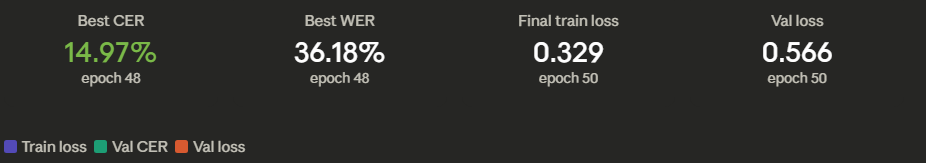

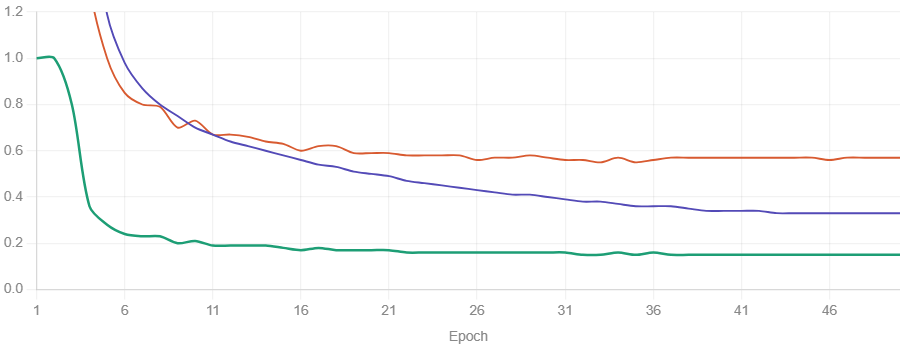

#UPDATES

In [ ]:
from torch.nn.utils.rnn import pad_sequence

def htr_collate_fn(batch):
    images = [item[0] for item in batch]
    labels = [item[1].long() if isinstance(item[1], torch.Tensor)
              else torch.tensor(item[1], dtype=torch.long)
              for item in batch]

    lengths = torch.tensor([len(label) for label in labels], dtype=torch.long)

    images = torch.stack(images, dim=0)
    labels = pad_sequence(labels, batch_first=True, padding_value=0)

    return images, labels, lengths

In [ ]:
import math
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Tuple, List, Dict

import torch
import torch.nn as nn
import torchvision.models as models
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

# Removed imports from htr_dataset and htr_train since they are defined in this notebook

In [ ]:
class Config:
    HF_DATASET_NAME   = "Teklia/IAM-line"

    IMG_HEIGHT        = 64
    MAX_IMG_WIDTH     = 1280
    IMG_CHANNELS      = 1
    KEEP_ASPECT_RATIO = True
    PAD_VALUE         = 255

    ALPHABET          = " !\"#&'()*+,-./0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
    BLANK_IDX         = 0
    NUM_CLASSES       = len(ALPHABET) + 1   # 81

    BATCH_SIZE        = 16
    NUM_WORKERS       = 0
    MAX_LABEL_LEN     =80
    USE_AUGMENT       = True

In [ ]:
@dataclass
class ModelConfig:
    img_height   : int   = 64
    img_channels : int   = 1
    max_img_width: int   = 1280
    num_classes  : int   = 81

    lstm_hidden  : int   = 384
    lstm_layers  : int   = 3
    lstm_dropout : float = 0.4
    head_dropout : float = 0.2

In [ ]:
@dataclass
class TrainConfig:
    num_epochs    : int   = 50
    learning_rate : float = 3e-4
    weight_decay  : float = 1e-4
    grad_clip     : float = 5.0

    checkpoint_dir: str   = "checkpoints_v2"
    save_every    : int   = 5
    keep_best     : bool  = True
    log_every     : int   = 100

    patience      : int   = 10
    min_delta     : float = 0.001

In [ ]:
class ResNetBackbone(nn.Module):
    """
    ResNet34, grayscale giriş için düzenlenmiş.

    Stride analizi (IMG_HEIGHT=64, MAX_IMG_WIDTH=1280):
      conv1 stride=2 + maxpool stride=2  →  H=16,  W=320
      layer1  stride=1                   →  H=16,  W=320
      layer2  stride=2                   →  H=8,   W=160
      layer3  stride=2                   →  H=4,   W=80
      layer4  stride=2 (default)         →  H=2,   W=40   ← T=40, CTC patlar!
      layer4  stride=1 (fixed)           →  H=4,   W=80   ← T=80 ✓

    feature_size = 512 × 4 = 2048
    sequence_len = 80   (MAX_LABEL_LEN=100 > 80 → dikkat! ama çoğu satır <80 char)

    NOT: MAX_LABEL_LEN=100 olan bazı çok uzun satırlar hâlâ sıfırlanabilir.
    Çözüm ya MAX_LABEL_LEN=80 ya da layer3'ü de stride=1 yapmak.
    Şimdilik MAX_LABEL_LEN=80 öneriyoruz.
    """

    def __init__(self, cfg: ModelConfig):
        super().__init__()

        resnet = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)

        # 1) İlk conv: 3ch → 1ch (grayscale)
        #    ImageNet ağırlıklarını korumak için ortalama al
        old_weight = resnet.conv1.weight.data.mean(dim=1, keepdim=True)
        resnet.conv1 = nn.Conv2d(
            cfg.img_channels, 64,
            kernel_size=7, stride=2, padding=3, bias=False
        )
        resnet.conv1.weight.data = old_weight

        # 2) Layer4 stride fix: (2,2) → (1,1)
        #    ResNet34 layer4[0] → BasicBlock: conv1 stride=(1,1), conv2 stride=(1,1)
        #    Ama downsample stride=(2,2) → bunu da düzelt
        #    ResNet34'te stride layer4[0].conv1 değil conv2'de olabilir,
        #    bu yüzden tüm conv'ları tara
        for block in resnet.layer4:
            # BasicBlock içindeki tüm Conv2d'leri bul
            for name, module in block.named_modules():
                if isinstance(module, nn.Conv2d):
                    if module.stride == (2, 2):
                        module.stride = (1, 1)
            # downsample (shortcut) conv
            if block.downsample is not None:
                for module in block.downsample.modules():
                    if isinstance(module, nn.Conv2d):
                        if module.stride == (2, 2):
                            module.stride = (1, 1)

        self.features = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,
            resnet.layer1,
            resnet.layer2,
            resnet.layer3,
            resnet.layer4,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.features(x)   # [B, 512, H', W']


In [ ]:
class HTRModel(nn.Module):

    def __init__(self, cfg: ModelConfig = ModelConfig()):
        super().__init__()
        self.cfg = cfg

        # CNN
        self.cnn = ResNetBackbone(cfg)

        # Feature size — dummy forward ile güvenli hesap
        with torch.no_grad():
            dummy = torch.zeros(1, cfg.img_channels, cfg.img_height, cfg.max_img_width)
            out   = self.cnn(dummy)   # cfg.img_height × cfg.max_img_width
            _, C, H, W = out.shape
            self.feature_size = C * H
            self.seq_len      = W

        # BiLSTM
        self.lstm = nn.LSTM(
            input_size    = self.feature_size,
            hidden_size   = cfg.lstm_hidden,
            num_layers    = cfg.lstm_layers,
            bidirectional = True,
            dropout       = cfg.lstm_dropout if cfg.lstm_layers > 1 else 0.0,
            batch_first   = False,
        )

        # CTC Head
        self.head = nn.Sequential(
            nn.Dropout(cfg.head_dropout),
            nn.Linear(cfg.lstm_hidden * 2, cfg.num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feat = self.cnn(x)                    # [B, C, H', W']
        B, C, H_, W_ = feat.shape
        feat = feat.view(B, C * H_, W_)       # [B, feature_size, T]
        feat = feat.permute(2, 0, 1)          # [T, B, feature_size]
        feat, _ = self.lstm(feat)             # [T, B, hidden*2]
        logits = self.head(feat)              # [T, B, num_classes]
        return torch.log_softmax(logits, dim=-1)

    def model_summary(self):
        total  = sum(p.numel() for p in self.parameters())
        train_ = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print("=" * 55)
        print("HTR Model v2  —  ResNet34 + BiLSTM + CTC")
        print("=" * 55)
        print(f"  CNN out      : [512, {self.feature_size // 512}, {self.seq_len}]  (C, H', W')")
        print(f"  feature_size : {self.feature_size}  (512 × {self.feature_size // 512})")
        print(f"  seq_len (T)  : {self.seq_len}")
        print(f"  lstm_hidden  : {self.cfg.lstm_hidden} × 2 = {self.cfg.lstm_hidden * 2}")
        print(f"  lstm_layers  : {self.cfg.lstm_layers}")
        print(f"  num_classes  : {self.cfg.num_classes}")
        print(f"  Total params : {total:,}")
        print(f"  Trainable    : {train_:,}")
        print("=" * 55)
        if self.seq_len < 100:
            print(f"  ⚠ T={self.seq_len} < MAX_LABEL_LEN=100")
            print(f"    Öneri: Config.MAX_LABEL_LEN = {self.seq_len} yap")
        else:
            print(f"  ✓ T={self.seq_len} >= MAX_LABEL_LEN=100")
        print("=" * 55)


In [ ]:
def ctc_greedy_decode(logits: torch.Tensor, tokenizer) -> List[str]:
    """logits: [T, B, C]"""
    preds = logits.argmax(-1)   # [T, B]
    T, B  = preds.shape
    results = []
    for b in range(B):
        prev, text = None, ""
        for t in range(T):
            c = preds[t, b].item()
            if c != tokenizer.blank_idx and c != prev:
                text += tokenizer.idx2char.get(c, "")
            prev = c
        results.append(text)
    return results


def _log_add(a: float, b: float) -> float:
    NEG_INF = float("-inf")
    if a == NEG_INF: return b
    if b == NEG_INF: return a
    if a > b: return a + math.log1p(math.exp(b - a))
    return b + math.log1p(math.exp(a - b))


def ctc_beam_search_decode(
    logits    : torch.Tensor,   # [T, B, C] — log_softmax
    tokenizer,
    beam_width: int = 10,
) -> List[str]:
    """Düzeltilmiş CTC beam search — log-prob + blank/repeat kuralı."""
    T, B, C   = logits.shape
    log_probs = logits.detach().cpu().float()
    blank_idx = tokenizer.blank_idx
    NEG_INF   = float("-inf")
    results   = []

    for b in range(B):
        lp    = log_probs[:, b, :]
        beams : Dict[tuple, Tuple[float, float]] = {(): (0.0, NEG_INF)}

        for t in range(T):
            new_beams: Dict[tuple, Tuple[float, float]] = {}
            topk_lp, topk_ci = lp[t].topk(min(beam_width * 2, C))

            for seq, (pb, pnb) in beams.items():
                p_total = _log_add(pb, pnb)

                # blank
                new_pb = p_total + lp[t, blank_idx].item()
                old    = new_beams.get(seq, (NEG_INF, NEG_INF))
                new_beams[seq] = (_log_add(old[0], new_pb), old[1])

                # non-blank
                for lp_c, ci in zip(topk_lp.tolist(), topk_ci.tolist()):
                    if ci == blank_idx:
                        continue
                    if len(seq) > 0 and seq[-1] == ci:
                        new_pnb = pb + lp[t, ci].item()
                    else:
                        new_pnb = p_total + lp[t, ci].item()
                    new_seq = seq + (ci,)
                    old     = new_beams.get(new_seq, (NEG_INF, NEG_INF))
                    new_beams[new_seq] = (old[0], _log_add(old[1], new_pnb))

            beams = dict(
                sorted(new_beams.items(),
                       key=lambda x: _log_add(x[1][0], x[1][1]),
                       reverse=True)[:beam_width]
            )

        best = max(beams, key=lambda s: _log_add(beams[s][0], beams[s][1]))
        results.append("".join(tokenizer.idx2char.get(i, "") for i in best))

    return results

In [ ]:
class Trainer:

    def __init__(self, model, train_dl, val_dl, tokenizer,
                 cfg: TrainConfig = TrainConfig(),
                 model_cfg: ModelConfig = ModelConfig()):
        self.model    = model
        self.train_dl = train_dl
        self.val_dl   = val_dl
        self.tok      = tokenizer
        self.cfg      = cfg
        self.device   = next(model.parameters()).device

        self.ctc_loss  = nn.CTCLoss(blank=0, zero_infinity=True, reduction="mean")
        self.optimizer = AdamW(model.parameters(),
                               lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
        self.scheduler = OneCycleLR(
            self.optimizer,
            max_lr          = cfg.learning_rate,
            epochs          = cfg.num_epochs,
            steps_per_epoch = len(train_dl),
            pct_start       = 0.1,
            anneal_strategy = "cos",
        )

        self.ckpt_dir  = Path(cfg.checkpoint_dir)
        self.ckpt_dir.mkdir(parents=True, exist_ok=True)
        self.best_cer  = float("inf")
        self.no_improve = 0
        self.history   = {"train_loss": [], "val_loss": [], "val_cer": [], "val_wer": []}

    # ── train ──────────────────────────────────────────

    def _train_epoch(self, epoch: int) -> float:
        self.model.train()
        total_loss, t0 = 0.0, time.time()

        for batch_idx, (imgs, labels, label_lengths) in enumerate(self.train_dl, 1):
            imgs          = imgs.to(self.device)
            labels        = labels.to(self.device)
            label_lengths = label_lengths.to(self.device)

            logits = self.model(imgs)
            T, B, _ = logits.shape

            input_lengths = torch.full((B,), T, dtype=torch.long, device=self.device)
            labels_flat   = torch.cat([labels[i, :label_lengths[i]] for i in range(B)])

            loss = self.ctc_loss(logits, labels_flat, input_lengths, label_lengths)

            self.optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.grad_clip)
            self.optimizer.step()
            self.scheduler.step()

            total_loss += loss.item()

            if batch_idx % self.cfg.log_every == 0:
                lr = self.scheduler.get_last_lr()[0]
                print(f"  Epoch {epoch:3d} | batch {batch_idx:4d}/{len(self.train_dl)} "
                      f"| loss {loss.item():.4f} | lr {lr:.2e} | {time.time()-t0:.0f}s")

        return total_loss / len(self.train_dl)

    # ── validate ───────────────────────────────────────

    @torch.no_grad()
    def _validate(self) -> dict:
        self.model.eval()
        total_loss, all_preds, all_targets = 0.0, [], []

        for imgs, labels, label_lengths in self.val_dl:
            imgs          = imgs.to(self.device)
            labels        = labels.to(self.device)
            label_lengths = label_lengths.to(self.device)

            logits = self.model(imgs)
            T, B, _ = logits.shape

            input_lengths = torch.full((B,), T, dtype=torch.long, device=self.device)
            labels_flat   = torch.cat([labels[i, :label_lengths[i]] for i in range(B)])

            loss = self.ctc_loss(logits, labels_flat, input_lengths, label_lengths)
            total_loss += loss.item()

            preds   = ctc_greedy_decode(logits, self.tok)
            targets = ["".join(self.tok.idx2char[c] for c in labels[i, :label_lengths[i]].tolist())
                       for i in range(B)]

            all_preds   += preds
            all_targets += targets

        avg_loss = total_loss / len(self.val_dl)
        cer      = compute_cer(all_preds, all_targets)
        wer      = compute_wer(all_preds, all_targets)

        return {"loss": avg_loss, "cer": cer, "wer": wer,
                "preds": all_preds[:4], "targets": all_targets[:4]}

    # ── checkpoint ─────────────────────────────────────

    def _save_checkpoint(self, epoch: int, tag: str = "") -> Path:
        fname = self.ckpt_dir / f"htr_epoch{epoch:03d}{tag}.pt"
        torch.save({
            "epoch": epoch,
            "model_state": self.model.state_dict(),
            "optim_state": self.optimizer.state_dict(),
            "sched_state": self.scheduler.state_dict(),
            "best_cer":    self.best_cer,
            "history":     self.history,
        }, fname)
        print(f"[Checkpoint saved] {fname}")
        return fname

    def load_checkpoint(self, path: str) -> int:
        ckpt = torch.load(path, map_location=self.device)
        self.model.load_state_dict(ckpt["model_state"])
        self.optimizer.load_state_dict(ckpt["optim_state"])
        self.scheduler.load_state_dict(ckpt["sched_state"])
        self.best_cer  = ckpt.get("best_cer", float("inf"))
        self.history   = ckpt.get("history", self.history)
        print(f"[Checkpoint loaded] epoch={ckpt['epoch']}  best_cer={self.best_cer:.4f}")
        return ckpt["epoch"]

    # ── fit ────────────────────────────────────────────

    def fit(self, start_epoch: int = 1):
        print("=" * 60)
        print(f"Training started — {self.cfg.num_epochs} epochs | device={self.device}")
        print("=" * 60)

        for epoch in range(start_epoch, self.cfg.num_epochs + 1):
            train_loss = self._train_epoch(epoch)
            val        = self._validate()

            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val["loss"])
            self.history["val_cer"].append(val["cer"])
            self.history["val_wer"].append(val["wer"])

            print(f"\nEpoch {epoch:3d}/{self.cfg.num_epochs} "
                  f"| train_loss {train_loss:.4f} | val_loss {val['loss']:.4f} "
                  f"| CER {val['cer']:.4f} | WER {val['wer']:.4f}")

            for pred, target in zip(val["preds"][:2], val["targets"][:2]):
                print(f"  GT  : '{target}'")
                print(f"  PRED: '{pred}'")

            if val["cer"] < self.best_cer - self.cfg.min_delta:
                self.best_cer   = val["cer"]
                self.no_improve = 0
                if self.cfg.keep_best:
                    self._save_checkpoint(epoch, tag="_best")
                    print(f"  ✓ New best CER: {self.best_cer:.4f}")
            else:
                self.no_improve += 1

            if epoch % self.cfg.save_every == 0:
                self._save_checkpoint(epoch)

            if self.no_improve >= self.cfg.patience:
                print(f"\n[Early Stop] {self.cfg.patience} epochs without improvement")
                break
            print()

        print("=" * 60)
        print(f"Training finished. Best val CER: {self.best_cer:.4f}")
        print("=" * 60)
        return self.history

In [ ]:
if __name__ == "__main__":

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[Device] {device}")

    # sanity check
    model = HTRModel(ModelConfig(num_classes=len(tok))).to(device)
    model.model_summary()

    dummy = torch.zeros(2, 1, Config.IMG_HEIGHT, Config.MAX_IMG_WIDTH).to(device)
    with torch.no_grad():
        logits = model(dummy)

    print(f"\nForward: {list(dummy.shape)} → {list(logits.shape)}")
    assert logits.shape[0] >= 80, f"T={logits.shape[0]} çok küçük! Stride fix çalışmadı."
    print("✓ Stride fix OK\n")

    # dataset
    train_dl, val_dl, test_dl, tok = make_dataloaders(cfg=Config)
    print(f"train={len(train_dl.dataset)}  val={len(val_dl.dataset)}  test={len(test_dl.dataset)}")

    # train
    model = HTRModel(ModelConfig(num_classes=len(tok))).to(device)

    train_cfg = TrainConfig(
        num_epochs=50,
        learning_rate=3e-4,
        log_every=100
    )

    trainer = Trainer(model, train_dl, val_dl, tok, train_cfg)
    history = trainer.fit()

[Device] cpu
HTR Model v2  —  ResNet34 + BiLSTM + CTC
  CNN out      : [512, 4, 80]  (C, H', W')
  feature_size : 2048  (512 × 4)
  seq_len (T)  : 80
  lstm_hidden  : 384 × 2 = 768
  lstm_layers  : 3
  num_classes  : 80
  Total params : 35,907,344
  Trainable    : 35,907,344
  ⚠ T=80 < MAX_LABEL_LEN=100
    Öneri: Config.MAX_LABEL_LEN = 80 yap

Forward: [2, 1, 64, 1280] → [80, 2, 80]
✓ Stride fix OK

[HF] 'Teklia/IAM-line' loading...
[HF] Splits: {'train': 6482, 'validation': 976, 'test': 2915}
[test] 8 örnek filtrelendi (boş, alphabet dışı veya label_len > 80)
[Dataset] train=6482  val=976  test=2907
train=6482  val=976  test=2907
Training started — 50 epochs | device=cpu


False
0
No GPU
